# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:
from rich import print
from tpvalidator.workspace import TriggerActivityWorkspace

import mplhep as hep
import matplotlib.pyplot as plt
import matplotlib as mpl
import hist
import mplhep as hep

# Data

In [3]:
# taws = TriggerActivityWorkspace('../../../radbkg_5000.root', 'taFinder')
# taws = TriggerActivityWorkspace('../../../data/vd/1x8x14/ta_finder/ta-finder_vd-1x8x14-radbkg.root', 'taFinder')
# taws = TriggerActivityWorkspace('../../../data/vd/1x8x14/ta_finder/ta-finder_vd-1x8x14-eminus.root', 'taFinder')
# taws = TriggerActivityWorkspace('../../../data/vd/1x8x14/ta_finder/ta-finder_vd-1x8x14-eminus_nobkg.root', 'taFinder')
# taws = TriggerActivityWorkspace('../../../data/vd/1x8x14/ta_finder/ta-finder_vd-1x8x14-eminus_3tps.root', 'taFinder')
taws = TriggerActivityWorkspace('../../../data/vd/1x8x14/ta_finder/eminus_0000.root', 'taFinder')


Key 'ta_win_cluster_stats' not found in file.


# Analysis

In [ ]:
from typing import Literal
import numpy as np
import hist
from scipy.stats import binom


def histogram_ratio(
    h_num: hist.Hist,
    h_den: hist.Hist,
    mode: Literal["independent", "binomial", "clopper-pearson"] = "independent",
    cl: float = 0.68,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute the ratio of two histograms with appropriate uncertainty.

    Parameters
    ----------
    h_num : hist.Hist
        Numerator histogram (Weight() storage).
    h_den : hist.Hist
        Denominator histogram (Weight() storage).
    mode : str
        - "independent"      : standard error propagation (two uncorrelated samples)
        - "binomial"         : symmetric binomial errors (numerator is subset of denominator)
        - "clopper-pearson"  : exact binomial interval, asymmetric, always within [0, 1]
    cl : float
        Confidence level for clopper-pearson intervals (default 0.68 ≈ 1σ).

    Returns
    -------
    ratio    : np.ndarray  (nan where undefined)
    err_lo   : np.ndarray  lower uncertainty
    err_hi   : np.ndarray  upper uncertainty (== err_lo except for clopper-pearson)
    """
    a, b   = h_num.values(), h_den.values()
    va, vb = h_num.variances(), h_den.variances()

    if va is None or vb is None:
        raise ValueError("Both histograms must use Weight() storage.")

    mask = (a >= 0) & (b > 0)

    with np.errstate(invalid="ignore", divide="ignore"):

        ratio = np.where(mask, a / b, np.nan)

        if mode == "independent":
            err = np.where(mask, ratio * np.sqrt(va / a**2 + vb / b**2), np.nan)
            # guard against a == 0 (ratio is 0, err reduces to sqrt(vb)/b)
            zero_num = mask & (a == 0)
            err = np.where(zero_num, np.sqrt(vb) / b, err)
            err_lo = err_hi = err

        elif mode == "binomial":
            err = np.where(mask, np.sqrt(ratio * (1 - ratio) / b), np.nan)
            err_lo = err_hi = err

        elif mode == "clopper-pearson":
            alpha = 1 - cl
            # use raw counts from values() as k and n
            k, n = a, b
            lo = np.where(mask, binom.ppf(    alpha / 2, n, ratio) / n, np.nan)
            hi = np.where(mask, binom.ppf(1 - alpha / 2, n, ratio) / n, np.nan)
            err_lo = np.where(mask, ratio - lo, np.nan)
            err_hi = np.where(mask, hi - ratio, np.nan)

        else:
            raise ValueError(f"Unknown mode '{mode}'. Choose from: independent, binomial, clopper-pearson.")

    return ratio, err_lo, err_hi



from tpvalidator.analysis.base import TrgWorkspaceAnalyzer
class SwiftTASignalAnalyzer(TrgWorkspaceAnalyzer):
    ...



In [5]:
taws.ta_event_selection

,,event_uid,event,run,subrun,max_win_sadc,max_win_cluster_sadc,tot_n_clusters,num_accept_win,num_inspect_win,num_inspect_accept_win,accepted
entry,subentry,,,,,,,,,,,
0,0,21000000001,1,21000,0,176679.107028,19950.0,4.0,1.0,3.0,0.0,True
100,0,21000000002,2,21000,0,33703.012512,25367.0,2.0,0.0,2.0,1.0,True
200,0,21000000003,3,21000,0,133741.418239,0.0,0.0,1.0,0.0,0.0,True
300,0,21000000004,4,21000,0,93330.590565,9373.0,2.0,1.0,1.0,0.0,True
400,0,21000000005,5,21000,0,154190.417322,0.0,0.0,1.0,0.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
9598,0,21000009996,96,21000,99,128659.416083,30868.0,2.0,1.0,3.0,2.0,True
9698,0,21000009997,97,21000,99,109394.585060,0.0,0.0,1.0,0.0,0.0,True
9798,0,21000009998,98,21000,99,177837.193731,8846.0,2.0,1.0,2.0,0.0,True


In [6]:
taws.mctruths
# [['event','run','subrun', 'kinetic_energy']]

,,event,run,subrun,pdg,process,status_code,block_id,truth_track_id,generator_name,x,y,z,t,px,py,pz,p,energy,kinetic_energy,event_uid
entry,subentry,,,,,,,,,,,,,,,,,,,,
0,0,1,21000,0,11,primary,1,0,-1,generator,244.417620,150.0,450.0,1000.0,0.013536,0.022261,0.079264,0.083436,0.083438,0.082927,21000000001
100,0,2,21000,0,11,primary,1,0,-1,generator,195.296624,150.0,450.0,1000.0,-0.010870,0.007094,0.001353,0.013051,0.013061,0.012550,21000000002
200,0,3,21000,0,11,primary,1,0,-1,generator,310.498101,150.0,450.0,1000.0,0.025864,-0.015079,-0.021332,0.036761,0.036764,0.036253,21000000003
300,0,4,21000,0,11,primary,1,0,-1,generator,-133.199120,150.0,450.0,1000.0,-0.035114,0.001327,-0.027515,0.044630,0.044633,0.044122,21000000004
400,0,5,21000,0,11,primary,1,0,-1,generator,287.648863,150.0,450.0,1000.0,0.046455,0.017164,-0.012472,0.051071,0.051073,0.050562,21000000005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9599,0,96,21000,99,11,primary,1,0,-1,generator,160.746530,150.0,450.0,1000.0,0.000467,0.065983,-0.000165,0.065985,0.065987,0.065476,21000009996
9699,0,97,21000,99,11,primary,1,0,-1,generator,-298.000649,150.0,450.0,1000.0,0.001085,-0.050287,-0.014981,0.052482,0.052484,0.051973,21000009997
9799,0,98,21000,99,11,primary,1,0,-1,generator,213.335684,150.0,450.0,1000.0,0.028817,-0.009798,0.064142,0.070998,0.071000,0.070489,21000009998


In [7]:
x = taws.ta_event_selection.merge(taws.mctruths[['event','run','subrun','event_uid','kinetic_energy']], on='event_uid')



<Axes: >

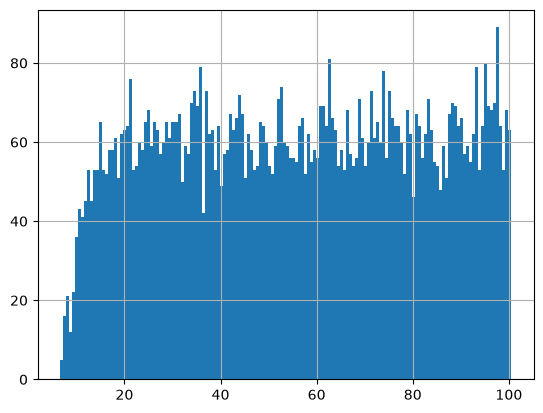

In [8]:
(x[x.accepted == True].kinetic_energy * 1000).hist(bins=150)

/var/folders/dw/sj94s2457kl2gkb829ty4_cc0000gn/T/ipykernel_26989/2550130208.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  taws.ta_event_selection.hist(ax=ax, bins=20)


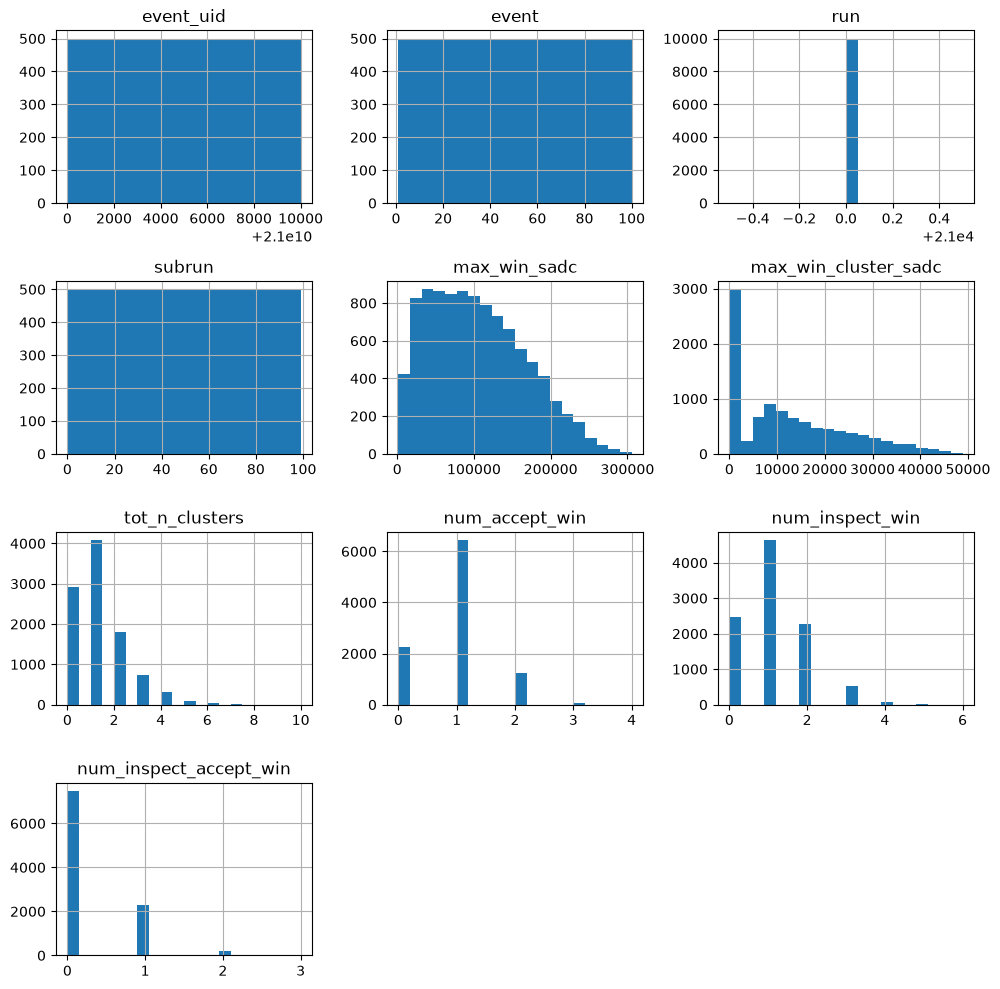

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1, figsize=(10,10))

taws.ta_event_selection.hist(ax=ax, bins=20)


fig.tight_layout()

In [10]:
taws.event_summary[['event_uid', 'event', 'run', 'subrun', 'tot_visible_energy_rop2']]
# ke_df = aws.mctruths[['event_uid', 'event', 'run', 'subrun', 'kinetic_energy','x', 'y', 'z']]

ev_sum = taws.event_summary[['event_uid', 'event', 'run', 'subrun', 'tot_visible_energy_rop2']].set_index('event_uid')
ev_sum = ev_sum.join(taws.mctruths[['event_uid', 'kinetic_energy','x', 'y', 'z']].set_index('event_uid'))
ev_sum = ev_sum.join(taws.ta_event_selection.drop(columns=['event', 'run', 'subrun']).set_index('event_uid'))
ev_sum['kinetic_energy'] *= 1000

In [11]:
taws.info

{'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8,
   'offset_V': 1,
   'offset_X': -7}},
 'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
 'mctruth_blockid_map': [[0, 'generator']],
 'tpg': {'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {'threshold_tpg_plane0': 36,
   'threshold_tpg_plane1': 36,
   'threshold_tpg_plane2': 36,
   'tool': 'TPAlgTPCSimpleThreshold'}},
 'tafinder_cfg': {'preselection': 'readout_view == 2 & samples_over_threshold >= 9',
  'ta_win_size': 1000,
  'ta_win_start': 0,
  'ta_inspect_sadc_min': 8000,
  'ta_inspect_sadc_max': 50000,
  'ta_inspect_cluster_sadc_threshold': 20750,
  'ta_win_sadc_dist_file': 'ta-win-sadc-vd-1x8x14-radbkg.root',
  'ta_win_sadc_dist_rdm_seed': 123,
  'ta_win_sadc_add_bkg': True,
  'ta_dbscan_epsilon': 2,
  'ta_dbscan_min_neigh': 2}}

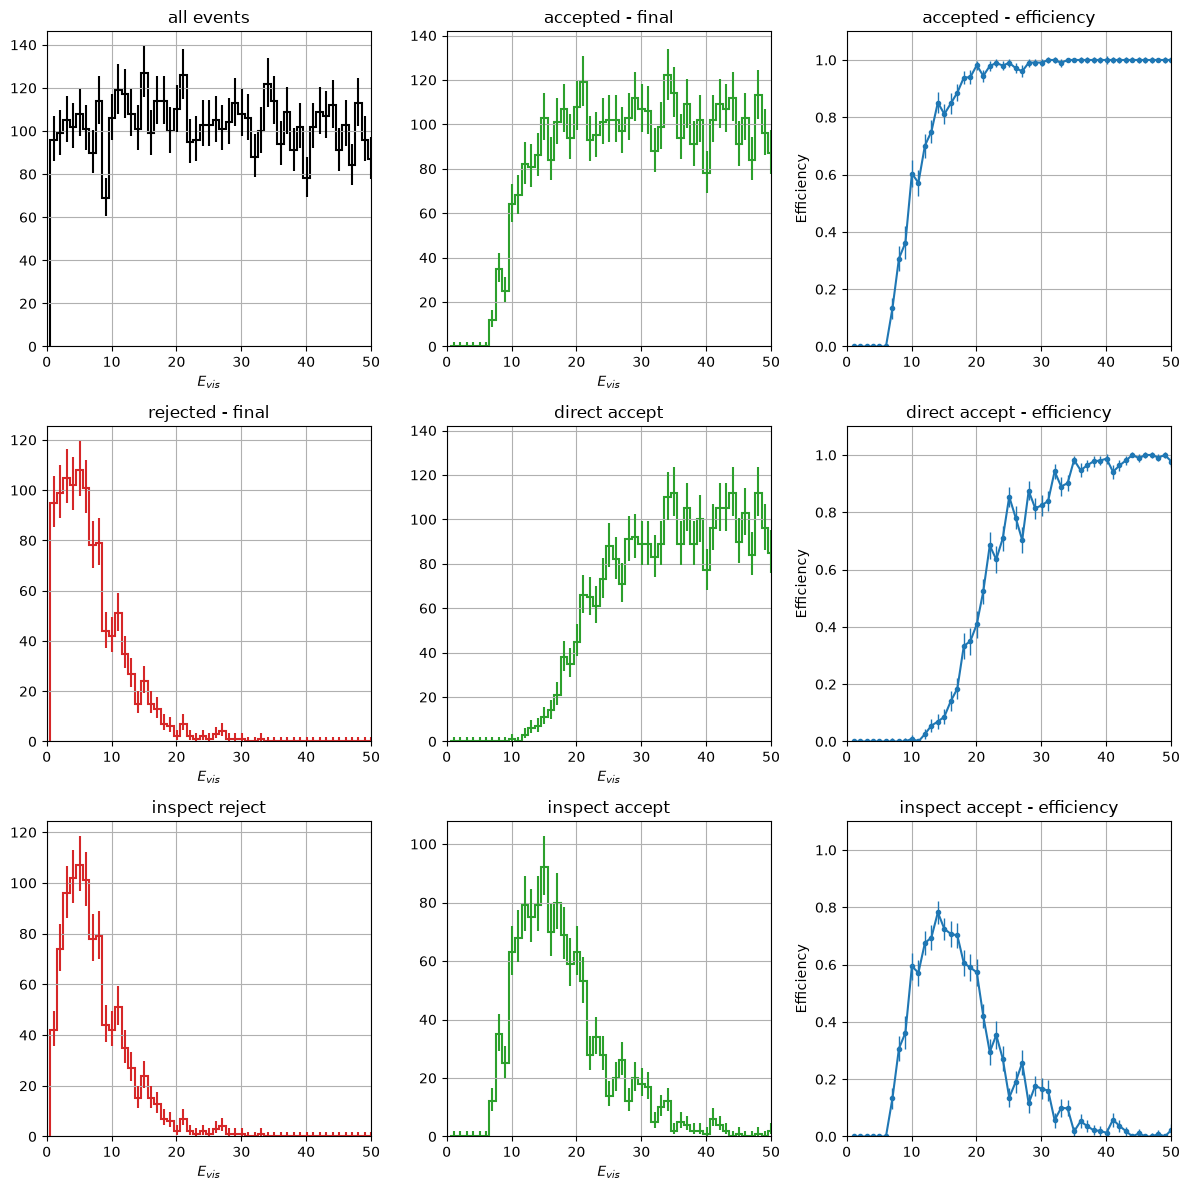

In [12]:
energy_var = 'kinetic_energy'
label='$E_{kin}$'

energy_var = 'tot_visible_energy_rop2'
label='$E_{vis}$'

from tpvalidator.analysis.histograms import make_regaxis
ke_ax = make_regaxis(ev_sum, energy_var, 1, label=label)


# ke_ax = hist.axis.Regular(99, 1, 100, name=label, flow=False)

h_ke = hist.Hist(ke_ax, storage=hist.storage.Weight())
h_ke.fill(ev_sum[energy_var])

h_ke_acc = hist.Hist(ke_ax, storage=hist.storage.Weight())
h_ke_acc.fill(ev_sum.query('accepted == True')[energy_var])

h_ke_rej = hist.Hist(ke_ax, storage=hist.storage.Weight())
h_ke_rej.fill(ev_sum.query('accepted == False')[energy_var])

h_ke_dir_acc = hist.Hist(ke_ax, storage=hist.storage.Weight())
h_ke_dir_acc.fill(ev_sum.query('num_accept_win > 0')[energy_var])

h_ke_insp_acc = hist.Hist(ke_ax, storage=hist.storage.Weight())
h_ke_insp_acc.fill(ev_sum.query('num_accept_win == 0 & num_inspect_accept_win > 0')[energy_var])

h_ke_insp_rej = hist.Hist(ke_ax, storage=hist.storage.Weight())
# h_ke_insp_rej.fill(ev_sum.query('num_accept_win == 0 & num_inspect_win > 0 & max_win_cluster_sadc < 7500')[energy_var])
h_ke_insp_rej.fill(ev_sum.query('num_accept_win == 0 & num_inspect_win > 0 & num_inspect_accept_win == 0')[energy_var])

# r = (h_ke_acc/h_ke)

# print(histogram_ratio(h_ke_acc, h_ke, 'clopper-pearson'))


xmin, xmax = 0, 50
cmap = mpl.colormaps['tab10']

fig,axes = plt.subplots(3,3, figsize=(12,12))

# All events
ax=axes[0][0]
hep.histplot(h_ke, ax=ax, color='k')
ax.grid()
ax.set_title('all events')
ax.set_xlim(xmin, xmax)

ax=axes[0][1]
hep.histplot(h_ke_acc, color=cmap(2), ax=ax)
ax.grid()
ax.set_title('accepted - final')
ax.set_xlim(xmin, xmax)

ax=axes[0][2]
# hep.histplot(r, ax=ax)
hep.comp.comparison(h_ke_acc, h_ke, comparison='efficiency', ax=ax, color=cmap(0), linestyle="-")
ax.grid()
ax.set_ylim(0,1.1)
ax.set_title('accepted - efficiency')
ax.set_xlim(xmin, xmax)


ax=axes[1,0]
hep.histplot(h_ke_rej, color=cmap(3), ax=ax)
ax.grid()
ax.set_title('rejected - final')
ax.set_xlim(xmin, xmax)

ax=axes[1,1]
hep.histplot(h_ke_dir_acc, color=cmap(2), ax=ax)
ax.grid()
ax.set_title('direct accept')
ax.set_xlim(xmin, xmax)

ax=axes[1,2]
hep.comp.comparison(h_ke_dir_acc, h_ke, comparison='efficiency', ax=ax, color=cmap(0), linestyle="-")
ax.grid()
ax.set_ylim(0,1.1)
ax.set_title('direct accept - efficiency')
ax.set_xlim(xmin, xmax)

ax=axes[2,0]
hep.histplot(h_ke_insp_rej,color=cmap(3), ax=ax)
ax.grid()
ax.set_title('inspect reject')
ax.set_xlim(xmin, xmax)

ax=axes[2,1]
hep.histplot(h_ke_insp_acc,color=cmap(2),  ax=ax)
ax.grid()
ax.set_title('inspect accept')
ax.set_xlim(xmin, xmax)


ax=axes[2,2]
hep.comp.comparison(h_ke_insp_acc, h_ke, comparison='efficiency', ax=ax, color=cmap(0), linestyle="-")
# hep.histplot(h_ke_insp_acc/h_ke, ax=ax)
ax.grid()
ax.set_title('inspect accept - efficiency')
ax.set_ylim(0,1.1)
ax.set_xlim(xmin, xmax)

fig.tight_layout()



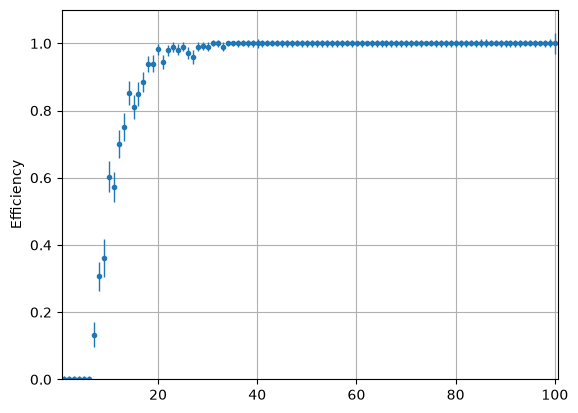

In [13]:
from mplhep.comp import get_efficiency, comparison

eff, err = get_efficiency(h_ke_acc, h_ke)


fig, ax = plt.subplots()
comparison(h_ke_acc, h_ke, comparison='efficiency', ax=ax, color=cmap(0), comparison_ylim=(0, 1.1))
ax.grid()



In [14]:
ev_sum.query('num_accept_win == 0 & num_inspect_win > 0 & num_inspect_accept_win > 0').query('tot_visible_energy_rop2 > 25')

,event,run,subrun,tot_visible_energy_rop2,kinetic_energy,x,y,z,max_win_sadc,max_win_cluster_sadc,tot_n_clusters,num_accept_win,num_inspect_win,num_inspect_accept_win,accepted
event_uid,,,,,,,,,,,,,,,
21000000120,20,21000,1,33.459472,33.912397,-243.212634,150.0,450.0,38036.229733,34961.0,4.0,0.0,2.0,2.0,True
21000000140,40,21000,1,30.362544,30.575260,-101.674274,150.0,450.0,45520.143499,35345.0,2.0,0.0,3.0,2.0,True
21000000158,58,21000,1,26.731804,27.289806,-267.330435,150.0,450.0,38874.621517,35468.0,2.0,0.0,2.0,1.0,True
21000000173,73,21000,1,33.618087,33.745797,165.829614,150.0,450.0,49796.528708,37406.0,3.0,0.0,2.0,2.0,True
21000000200,100,21000,1,33.919649,34.216246,-183.419293,150.0,450.0,38244.591208,23305.0,5.0,0.0,3.0,2.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21000009842,42,21000,98,30.775508,31.206718,-298.970813,150.0,450.0,49100.333936,24598.0,4.0,0.0,2.0,1.0,True
21000009858,58,21000,98,41.090649,41.514987,-270.348516,150.0,450.0,45981.523235,33948.0,3.0,0.0,3.0,2.0,True
21000009926,26,21000,99,29.790732,29.902178,121.813011,150.0,450.0,49397.564587,29097.0,4.0,0.0,3.0,2.0,True


In [15]:
ev_sum.query('num_accept_win == 0 & num_inspect_win > 0 & num_inspect_accept_win == 0').query('tot_visible_energy_rop2 > 25')

,event,run,subrun,tot_visible_energy_rop2,kinetic_energy,x,y,z,max_win_sadc,max_win_cluster_sadc,tot_n_clusters,num_accept_win,num_inspect_win,num_inspect_accept_win,accepted
event_uid,,,,,,,,,,,,,,,
21000000586,86,21000,5,27.445430,27.649156,-151.935321,150.0,450.0,46887.084067,12461.0,1.0,0.0,2.0,0.0,False
21000000701,1,21000,7,33.416288,33.820014,-234.107444,150.0,450.0,40347.265159,19073.0,6.0,0.0,3.0,0.0,False
21000001487,87,21000,14,25.796216,26.141540,-257.954159,150.0,450.0,27171.856150,11936.0,5.0,0.0,3.0,0.0,False
21000002142,42,21000,21,26.723112,32.383095,-246.000621,150.0,450.0,26932.821573,20335.0,4.0,0.0,3.0,0.0,False
21000003414,14,21000,34,27.085130,27.309407,-123.362887,150.0,450.0,37361.628414,15597.0,4.0,0.0,3.0,0.0,False
21000004357,57,21000,43,26.290295,26.558036,-308.065736,150.0,450.0,26814.086603,20547.0,5.0,0.0,3.0,0.0,False
21000004490,90,21000,44,26.097179,26.376173,-264.438888,150.0,450.0,31035.990167,17407.0,4.0,0.0,3.0,0.0,False
21000006772,72,21000,67,25.380697,25.756471,-320.655280,150.0,450.0,37873.020466,18315.0,2.0,0.0,2.0,0.0,False
21000008394,94,21000,83,30.360230,30.419254,81.217688,150.0,450.0,42214.703338,11093.0,1.0,0.0,3.0,0.0,False


In [16]:
taws.tree_names

['event_summary',
 'mctruths',
 'simide_summary',
 'ta_event_selection',
 'ta_win_stats',
 'ta_win_cluster_stats',
 'ta_clusters',
 'tps_with_cluster_flags']

In [17]:
from tpvalidator.viz.display import TriggerPrimitivesEventViewer

In [18]:
import tpvalidator.datacatalogue as dctl

em_ws =dctl.load('data/vd/1x8x14/tp_filtered', ['eminus'])['eminus']

Loading eminus

Key 'mcneutrinos' not found in file.
Key 'mcparticles' not found in file.
Key 'simides' not found in file.


Dataset 'eminus': 10000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 36,
            'threshold_tpg_plane1': 36,
            'threshold_tpg_plane2': 36,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Workspace radbkg_10 skipped

...

Workspace radbkg_1000 skipped

Workspace radbkg_5000 skipped

Workspace radbkg_10000 skipped

Workspace radbkg_20100 skipped

Workspace radbkg skipped

In [19]:
tpv = TriggerPrimitivesEventViewer(em_ws)



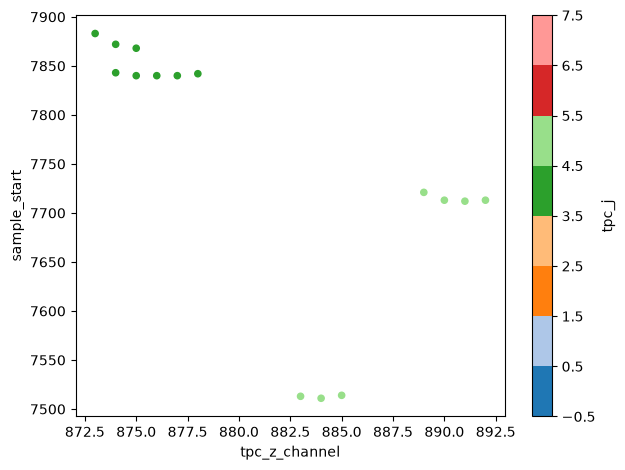

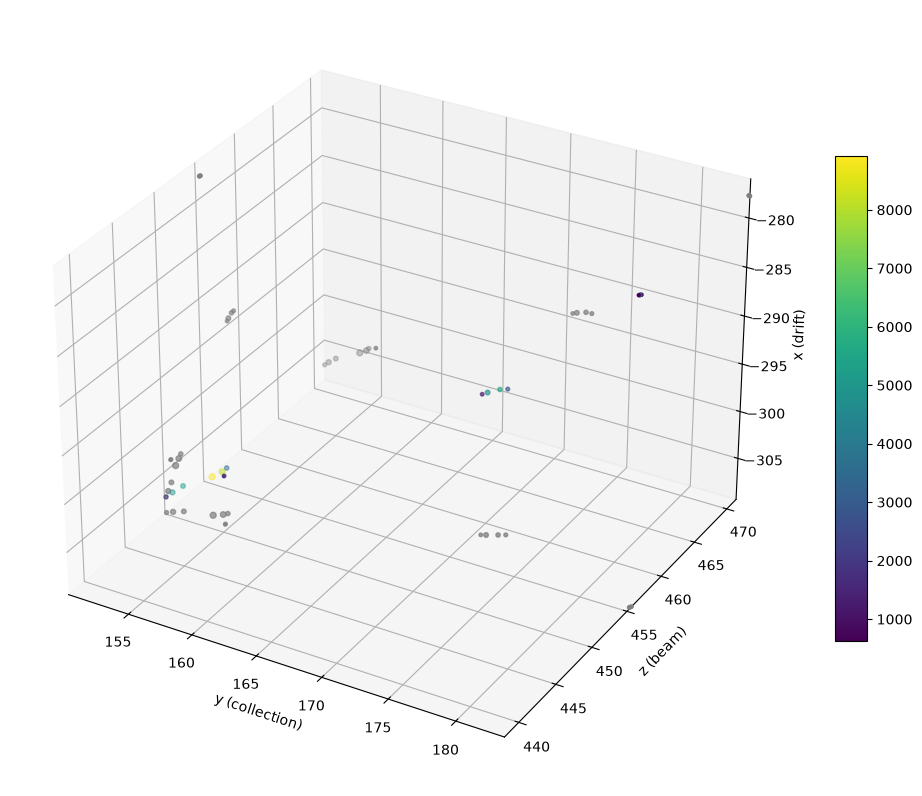

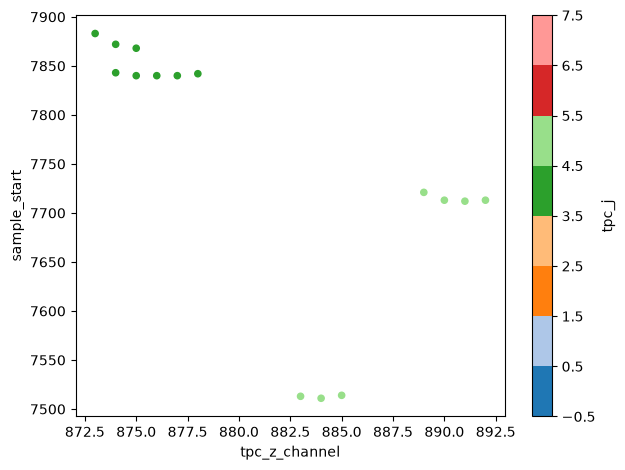

In [20]:
ev_uid = 21000008394
# ev_uid = 21000000007
ev_uid = 21000004357

tpv.draw_tps_point_of_origin(ev_uid, figsize=(10,10))

tpv.plot_yzt_event_view(ev_uid)


In [21]:
ev_sum.query('num_accept_win == 0 & num_inspect_accept_win > 0')

,event,run,subrun,tot_visible_energy_rop2,kinetic_energy,x,y,z,max_win_sadc,max_win_cluster_sadc,tot_n_clusters,num_accept_win,num_inspect_win,num_inspect_accept_win,accepted
event_uid,,,,,,,,,,,,,,,
21000000002,2,21000,0,12.518770,12.549880,195.296624,150.0,450.0,33703.012512,25367.0,2.0,0.0,2.0,1.0,True
21000000006,6,21000,0,20.642915,20.686461,192.182577,150.0,450.0,46181.352113,41368.0,2.0,0.0,2.0,1.0,True
21000000011,11,21000,0,12.322334,12.433979,-135.043868,150.0,450.0,33456.384106,24079.0,1.0,0.0,2.0,1.0,True
21000000022,22,21000,0,10.131731,10.149584,201.836020,150.0,450.0,32041.868289,27867.0,1.0,0.0,1.0,1.0,True
21000000024,24,21000,0,10.681590,10.740689,105.295661,150.0,450.0,27905.619706,26266.0,1.0,0.0,1.0,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21000009963,63,21000,99,23.703580,24.052379,-322.597739,150.0,450.0,35783.661852,29432.0,3.0,0.0,3.0,1.0,True
21000009965,65,21000,99,24.549949,24.669282,-259.874922,150.0,450.0,34815.316455,29237.0,3.0,0.0,3.0,1.0,True
21000009971,71,21000,99,13.767371,13.865369,-192.976576,150.0,450.0,35248.001461,27933.0,2.0,0.0,1.0,1.0,True


In [22]:
em_ws.tps.extra_info

{'readout_window': 8500,
 'num_entries': 10000,
 'event_list':        event    run  subrun
 entry                      
 0          1  21000       0
 1          2  21000       0
 2          3  21000       0
 3          4  21000       0
 4          5  21000       0
 ...      ...    ...     ...
 9995      96  21000      99
 9996      97  21000      99
 9997      98  21000      99
 9998      99  21000      99
 9999     100  21000      99
 
 [10000 rows x 3 columns]}

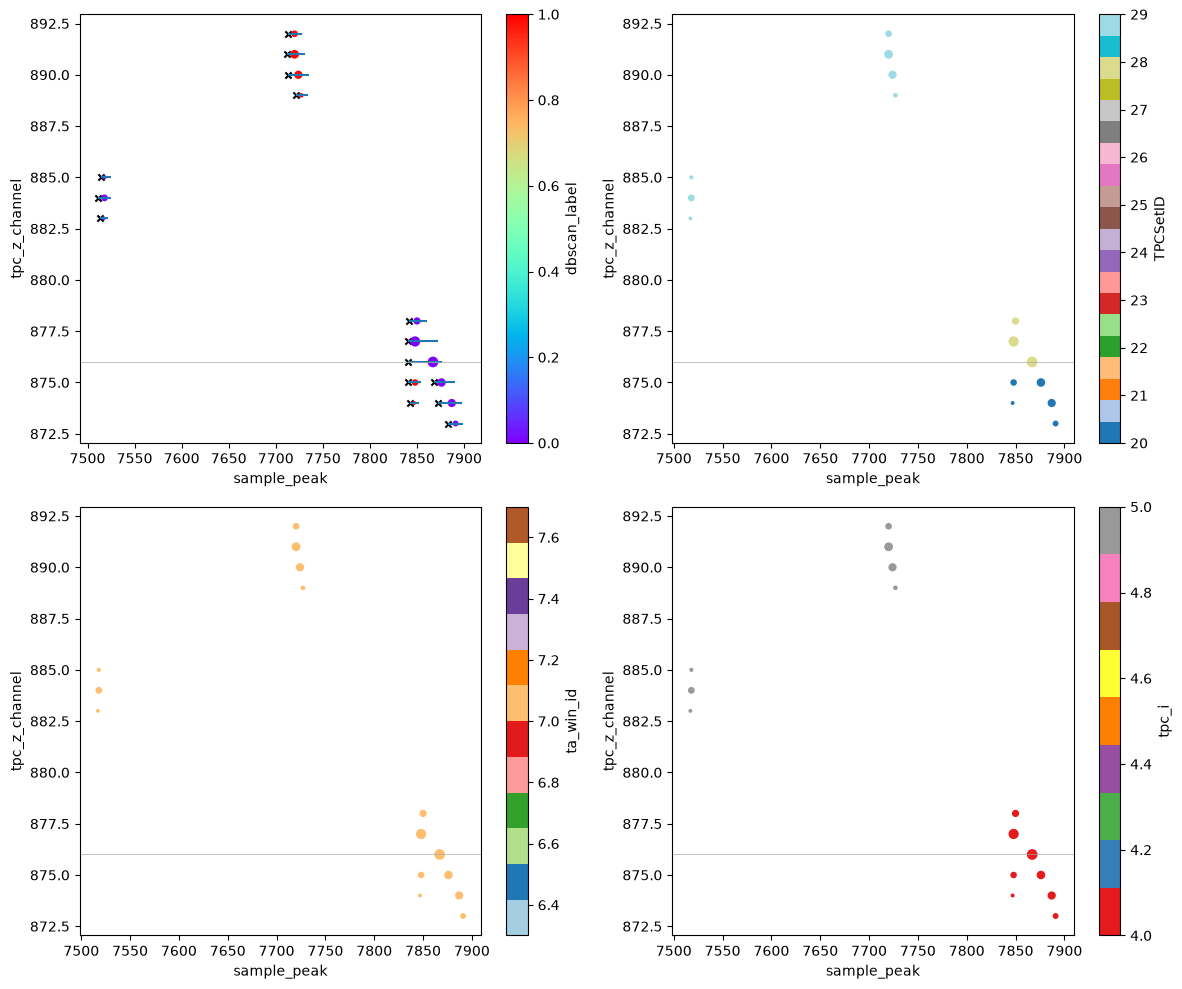

In [23]:
from tpvalidator.detgeometry import get_by_geocfg_id
import pandas as pd

geo = get_by_geocfg_id(em_ws.info['geo']['detector'])

def decorate_tpc_coords(tps, detgeo):

    tps['tpc_view_channel'] = tps.channel.apply(lambda c: detgeo.tpc_view_channel(c)[1]).astype('int16')
    tps[['tpc_i', 'tpc_k']] = pd.DataFrame(tps.TPCSetID.apply(detgeo.tpc_id_to_grid).tolist(), index=tps.index).rename({0:'tpc_i', 1:'tpc_k'}, axis=1)
    tps['tpc_z_channel'] = (tps['tpc_view_channel']+detgeo.tpc_view_2_num_chans_sim*tps['tpc_k']).where(tps['readout_view'] == 2, -1)


def draw_tawin_boundaries(ax):

    ymin, ymax = ax.get_ylim()
    for k in range(0, geo.tpc_geo[2]*geo.tpc_view_2_num_chans_sim, geo.tpc_view_2_num_chans_sim):
        if k < ymin or k > ymax:
            continue
        ax.axhline(k, c='darkgrey', lw=0.5)

    xmin, xmax = ax.get_xlim()
    for t in range(0, 8500, 1000):
        # print(t)
        if t < xmin or t > xmax:
            continue
        ax.axvline(t, c='darkgrey', lw=0.5)


decorate_tpc_coords(taws.tps_with_cluster_flags, geo)
tps_coll_ev = taws.tps_with_cluster_flags.query(f"event_uid=={ev_uid}")


fig, axes = plt.subplots(2,2, figsize=(12, 10))


ax = axes[0][0]

tps_coll_ev.plot.scatter(x='sample_start', y='tpc_z_channel', s=20, marker='x', c='k', ax=ax)
tps_coll_ev.plot.scatter(x='sample_peak', y='tpc_z_channel', s=tps_coll_ev['adc_integral']/200, c='dbscan_label', cmap='rainbow', ax=ax)

ax.hlines(y=tps_coll_ev.tpc_z_channel.values, xmin=tps_coll_ev.sample_start, xmax=(tps_coll_ev.sample_start+tps_coll_ev.samples_over_threshold))

draw_tawin_boundaries(ax)


ax = axes[0][1]

tps_coll_ev.plot.scatter(x='sample_peak', y='tpc_z_channel', s=tps_coll_ev['adc_integral']/200, c='TPCSetID', cmap='tab20', ax=ax)

draw_tawin_boundaries(ax)


ax = axes[1][0]

tps_coll_ev.plot.scatter(x='sample_peak', y='tpc_z_channel', s=tps_coll_ev['adc_integral']/200, c='ta_win_id', cmap='Paired', ax=ax)

draw_tawin_boundaries(ax)

ax = axes[1][1]

tps_coll_ev.plot.scatter(x='sample_peak', y='tpc_z_channel', s=tps_coll_ev['adc_integral']/200, c='tpc_i', cmap='Set1', ax=ax)

draw_tawin_boundaries(ax)

fig.tight_layout()


In [24]:
from tpvalidator.detgeometry import get_by_geocfg_id
detgeo = get_by_geocfg_id(taws.info['geo']['detector'])

Range1D(min=-753.9224000000002, max=753.9223999999999)

753.9223999999999

NameError: name 'y_range' is not defined

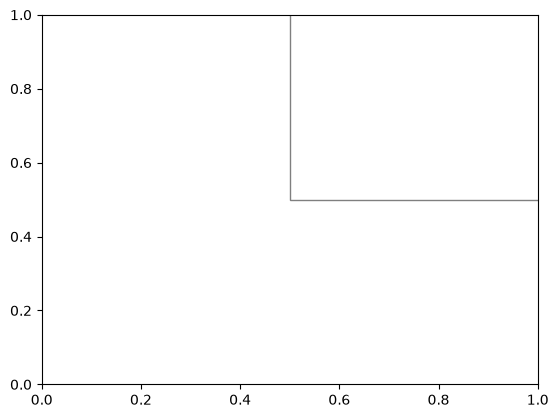

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots()

for tpc in detgeo.geo().tpcs:
    rect = patches.Rectangle((tpc.y_range.min, tpc.z_range.min), tpc.y_range.length, tpc.z_range.length, 
                            linewidth=1,
                          edgecolor='black',
                          facecolor='white',
                          alpha=0.5)
    # print(rect)
    ax.add_patch(rect)
    # break



# # Rectangle(xy, width, height, ...)
# rect = patches.Rectangle((0.2, 0.3), 0.4, 0.2,
#                           linewidth=2,
#                           edgecolor='blue',
#                           facecolor='lightblue',
#                           alpha=0.5)

# print(*detgeo.geo().cryostat.z_range)
print(detgeo.geo().cryostat.y_range)
print(detgeo.geo().cryostat.y_range.max)

ax.set_xlim(*detgeo.geo().cryostat.z_range)

# ax.set_xlim(*detgeo.geo().cryostat.z_range)
ax.set_ylim(y_range.min, y_range.max)
fig

print(*detgeo.geo().cryostat.y_range)